# 6.5.- Transformers y Large Language Models (LLMs)

Los modelos **Transformer** revolucionaron el NLP al eliminar la recurrencia y usar
mecanismos de **atención** que permiten procesar todas las palabras de una secuencia en paralelo.

Esto dio origen a los **Large Language Models (LLMs)** como *BERT, GPT, RoBERTa, T5, LLaMA* o *Gemini*.

En este notebook aprenderás a:

1. Usar modelos preentrenados de *Hugging Face Transformers*.  
2. Aplicar tareas comunes de NLP con `pipeline()`.  
3. Explorar embeddings contextuales.  
4. Generar texto controlando la creatividad (*temperature*).  
5. Realizar *question answering* con modelos de comprensión lectora.

In [6]:
from transformers import pipeline, AutoTokenizer, AutoModel
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)

## Introducción al modelo Transformer

Los **Transformers** reemplazan las redes recurrentes mediante el mecanismo de **self-attention**, que permite procesar todas las palabras de una secuencia en paralelo y captar relaciones de largo alcance.  
Esta arquitectura dio origen a modelos como **BERT** o **GPT**, base de los actuales **LLMs**.

En el código siguiente se usa un *pipeline* de **análisis de sentimiento** para clasificar frases en inglés como positivas o negativas.

In [21]:
# Pipeline de análisis de sentimiento
sentiment = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

examples = [
    "The movie was excellent, I loved every moment of it.",
    "I hate this restaurant, the food was cold and the service was terrible.",
    "The laptop works fine but the battery dies too fast.",
    "I’m really happy with this new phone, it’s amazing!"
]

for text in examples:
    print(text, "→", sentiment(text))

The movie was excellent, I loved every moment of it. → [{'label': 'POSITIVE', 'score': 0.999883770942688}]
I hate this restaurant, the food was cold and the service was terrible. → [{'label': 'NEGATIVE', 'score': 0.9997096657752991}]
The laptop works fine but the battery dies too fast. → [{'label': 'NEGATIVE', 'score': 0.9994076490402222}]
I’m really happy with this new phone, it’s amazing! → [{'label': 'POSITIVE', 'score': 0.999881386756897}]


## Embeddings contextuales

Los **embeddings contextuales** representan palabras según su contexto, de modo que una misma palabra puede tener vectores distintos dependiendo de la frase en la que aparece.

En el código siguiente comparamos los embeddings generados por *BERT* para dos frases con la palabra “bank” en distintos contextos.

In [20]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

sentences = [
    "The bank is next to the river.",
    "The bank approved the loan yesterday."
]

for sentence in sentences:
    inputs = tokenizer(sentence, return_tensors="pt")
    outputs = model(**inputs)
    print(f"\nSentence: {sentence}")
    print("Embedding shape:", outputs.last_hidden_state.shape)


Sentence: The bank is next to the river.
Embedding shape: torch.Size([1, 10, 768])

Sentence: The bank approved the loan yesterday.
Embedding shape: torch.Size([1, 9, 768])


## Question Answering

El **Question Answering (QA)** permite responder preguntas a partir de un texto dado.  
El modelo localiza el fragmento más relevante del contexto y devuelve la respuesta con un nivel de confianza.

En el código siguiente usamos un modelo entrenado con *SQuAD* para responder preguntas sobre un párrafo breve.

In [19]:
qa = pipeline("question-answering", model="distilbert-base-cased-distilled-squad")

context = """
Natural Language Processing (NLP) allows computers to understand human language
by analyzing both the literal meaning and the intent behind the words.
"""

question = "What does NLP allow computers to do?"

answer = qa({"context": context, "question": question})
print("Question:", question)
print("Answer:", answer["answer"])
print("Confidence:", round(answer["score"], 3))

Question: What does NLP allow computers to do?
Answer: understand human language
Confidence: 0.795


## Generación de texto con GPT-2

Los modelos generativos como **GPT-2** predicen la siguiente palabra a partir de las anteriores.  
El parámetro **temperature** controla la creatividad del texto generado:
- `temperature = 0.2` → texto más preciso y coherente.  
- `temperature = 1.5` → texto más creativo pero menos estable.

En el código siguiente generamos texto variando la temperatura para comparar estilos de salida.

In [18]:
generator = pipeline("text-generation", model="gpt2", pad_token_id=50256)

prompt = "Artificial intelligence in the future"

for T in [0.2, 1.0, 1.5]:
    print(f"\nTemperature = {T}\n")
    
    output = generator(
        prompt,
        max_new_tokens=60,
        temperature=T,
        do_sample=True,
        top_p=0.9,
        repetition_penalty=1.2,
        truncation=True
    )[0]["generated_text"]
    
    print(output)


Temperature = 0.2

Artificial intelligence in the future will be a big part of our lives.
The next step is to create artificial intelligences that can understand and respond better than humans, so we'll have more information about what's going on around us — not just how much it costs but also where people are living now."

Temperature = 1.0

Artificial intelligence in the future will be a challenge for every business, but one where companies can focus on their mission objectives.
"This is not something I'm going to sit back and think 'Oh boy.'"

Temperature = 1.5

Artificial intelligence in the future? Well…
There's a reason companies now have automated products built upon top code – there are no longer any limits. A developer or product creator still needs one step clear at each stage of development to make his ORD (One Big Programmer-Owned Object, No Problem) business scalable


## Visualización de la atención

Los **mapas de atención** muestran qué palabras influyen más unas en otras dentro del modelo.  
Cada celda de la matriz representa **cuánta atención dedica una palabra (eje Y)** a otra **(eje X)** al procesar la frase.

El color más intenso indica una **mayor atención**.  
Por ejemplo, si el token *“understand”* tiene valores altos hacia *“language”*, el modelo está reconociendo que esas palabras están **relacionadas semánticamente**.

En el gráfico siguiente se muestra el **promedio de atención de todos los *heads*** en la última capa del modelo BERT.

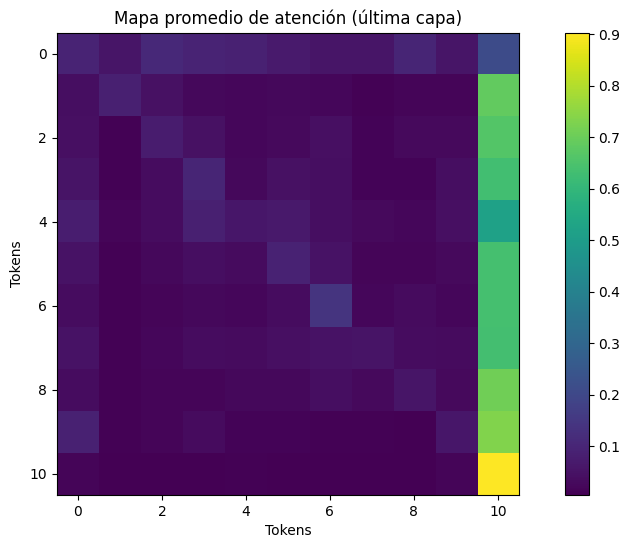

In [24]:
# Cargar modelo BERT configurado para devolver atenciones
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True)

# Frase de ejemplo en inglés
inputs = tokenizer("NLP allows machines to understand human language.", return_tensors="pt")

# Pasar los datos por el modelo con salida de atenciones
outputs = model(**inputs)

# Extraer la última capa de atención
attentions = outputs.attentions[-1][0].detach().numpy()

# Visualizar el mapa promedio de atención
plt.imshow(attentions.mean(axis=0))
plt.title("Mapa promedio de atención (última capa)")
plt.xlabel("Tokens")
plt.ylabel("Tokens")
plt.colorbar()
plt.show()

## Ejercicio Final

1. **Prueba otros modelos** en inglés o español, por ejemplo:  
   - `"distilbert-base-uncased-finetuned-sst-2-english"` (análisis de sentimiento)  
   - `"deepset/bert-base-cased-squad2"` (preguntas y respuestas)  
   - `"gpt2-medium"` (generación de texto más coherente)  

2. **Escribe tus propias frases** y analiza cómo cambian los resultados de sentimiento o las respuestas del modelo.  

3. **Experimenta con la temperatura** en la generación de texto y observa cómo varía la creatividad:  
   - `temperature = 0.2` → texto más lógico y repetitivo.  
   - `temperature = 1.5` → texto más imaginativo, pero menos coherente.

4. **(Opcional)**: Visualiza mapas de atención con distintas frases y comenta qué patrones descubres entre palabras relacionadas.